In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [4]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [68]:
pulse_header = "D:/K_sunada/result/control_pulses/"
fogi = "/2024-06-01/2024-06-01T190833_e791f89d-Control_Pulse"
fogi_tr = "/2024-06-01/2024-06-01T204847_e7bb0e65-Control_Pulse"
fogi_anti = "/2024-05-31/2024-05-31T105648_0a8ccd46-Control_Pulse"
fogi_anti_tr = "/2024-05-31/2024-05-31T110825_a9eb6157-Control_Pulse"

In [69]:
dd = datadict_from_hdf5(pulse_header+fogi+"/data")
dd_tr = datadict_from_hdf5(pulse_header+fogi_tr+"/data")
dd_anti = datadict_from_hdf5(pulse_header+fogi_anti+"/data")
dd_anti_tr = datadict_from_hdf5(pulse_header+fogi_anti_tr+"/data")
time = dd['time']['values']
fogi = dd['control_pulse']['values']
fogi_tr = dd_tr['control_pulse']['values']
fogi_anti = dd_anti['control_pulse']['values']
fogi_anti_tr = dd_anti_tr['control_pulse']['values']

<Figure size 800x300 with 0 Axes>

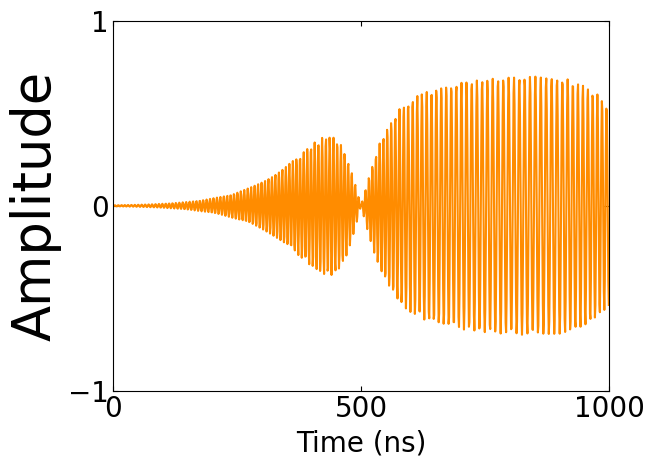

In [70]:
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'Amplitude',fontsize=38)
ax0.plot(time,  fogi_anti, '-',color='darkorange')# - np.mean(y_base))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-1, 1)
ax0.set_xlim(0, 1000)
# plt.legend()
plt.xticks(np.arange(0, 1001, 500))
plt.yticks(np.arange(-1, 1.1, 1))
# plt.savefig('fogi.png', bbox_inches='tight')
plt.show()

<Figure size 800x300 with 0 Axes>

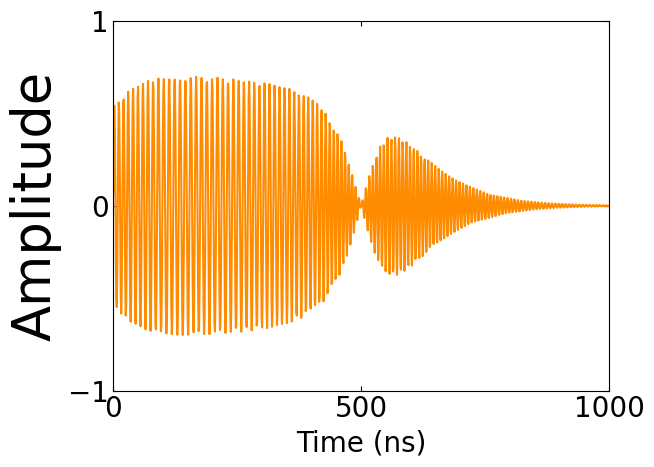

In [71]:
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'Amplitude',fontsize=38)
ax0.plot(time,  fogi_anti_tr, '-',color='darkorange')# - np.mean(y_base))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-1, 1)
ax0.set_xlim(0, 1000)
# plt.legend()
plt.xticks(np.arange(0, 1001, 500))
plt.yticks(np.arange(-1, 1.1, 1))
# plt.savefig('fogi_tr.png', bbox_inches='tight')
plt.show()

## 5/30 photon absorption

In [5]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [14]:
header = "D:/K_sunada/result/CDY159/"
fogi_timing = "/2024-06-02/2024-06-02T002313_dcb48687-75-sym_JPA_ab_fogi_timing"
fogi_timing1 = "/2024-06-02/2024-06-02T004945_9192671d-75-sym_JPA_ab_fogi_timing"
fogi_timing2 = "/2024-06-02/2024-06-02T011610_4262c9be-75-sym_JPA_ab_fogi_timing"

In [15]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_ref']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

[66.33863807 72.52696396 77.80721194 83.44303572 80.24410485 76.93585631
 76.85990403 58.26768649 52.62728465 45.87048201 38.6828065 ]


<Figure size 800x600 with 0 Axes>

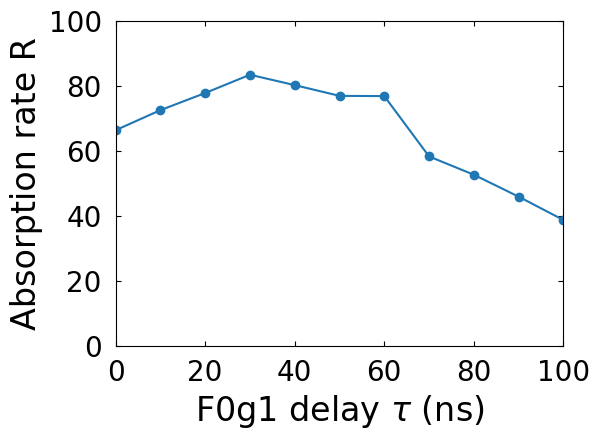

In [19]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_timing = 11
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 100)
# plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

[62.13213896 67.6575997  72.00360135 76.83133926 80.06560638 77.63191675
 76.67712456 76.13146903 73.66098359 71.96363276 68.72529606]


<Figure size 800x600 with 0 Axes>

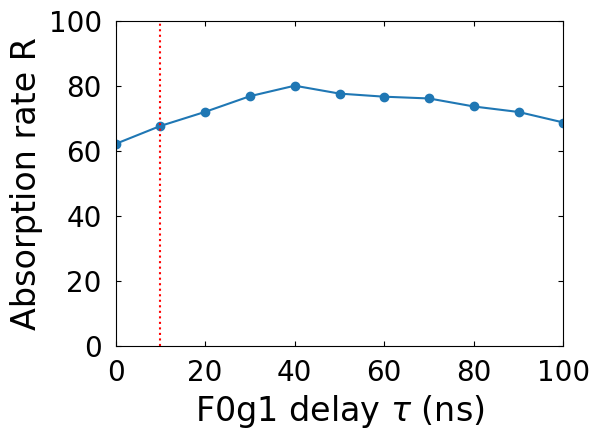

In [18]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing1
num_of_ph_amp = 1
num_of_fogi_timing = 11
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 100)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

[67.39379601 71.92052816 80.19427694 82.17221805 85.39692591 87.15062706
 91.0632048  92.14926779 92.66792449 90.8139672  90.57310853]


<Figure size 800x600 with 0 Axes>

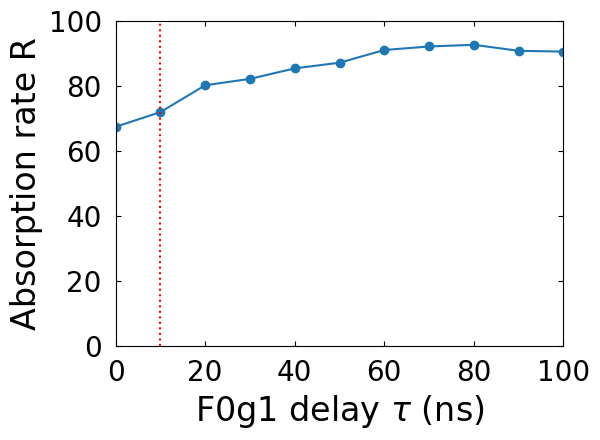

In [20]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing2
num_of_ph_amp = 1
num_of_fogi_timing = 11
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 100)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][17], d[0][ph_amp][17])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

93.0


<Figure size 800x300 with 0 Axes>

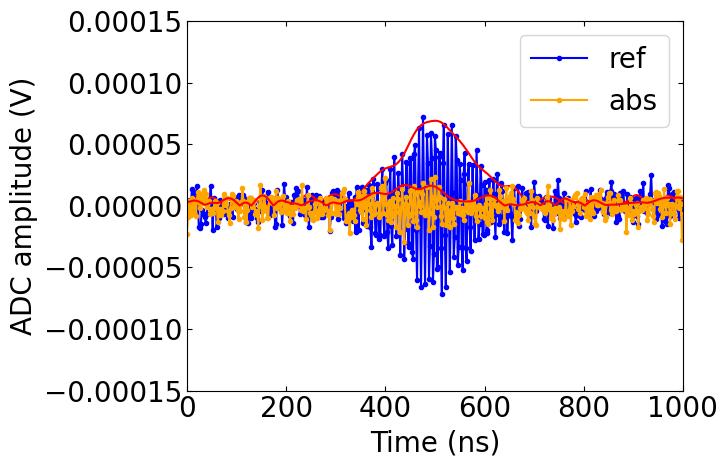

In [10]:
## waveform
ph_amp = 0
fogi_freq = 16
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_freq = 46
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

n_ave = 0.03?

In [10]:
fogi_1028 = "/2024-05-30/2024-05-30T221627_d239369f-75-sym_JPA_ab_fogi_timing"
fogi_1030 = "/2024-05-30/2024-05-30T222029_629d8a69-75-sym_JPA_ab_fogi_timing"
fogi_1032 = "/2024-05-30/2024-05-30T222431_f2ec9e64-75-sym_JPA_ab_fogi_timing"

87.54


<Figure size 800x300 with 0 Axes>

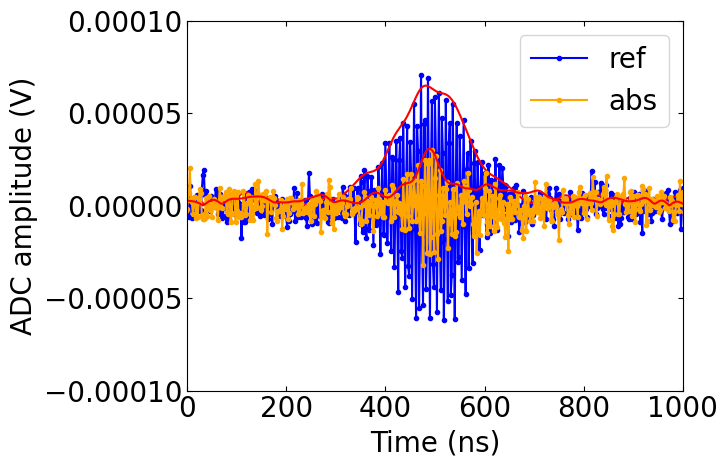

In [11]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1028
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 140e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

93.35


<Figure size 800x300 with 0 Axes>

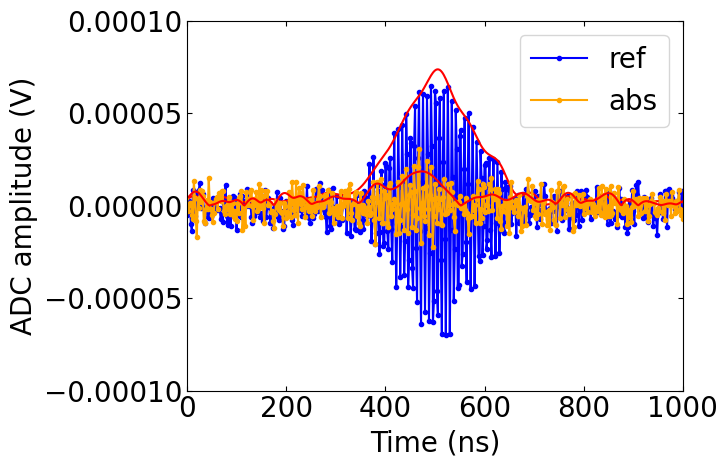

In [12]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1030
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

86.08


<Figure size 800x300 with 0 Axes>

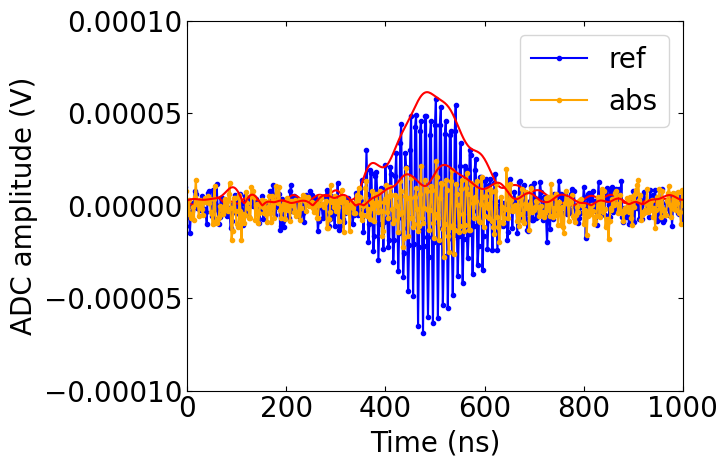

In [13]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1032
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

n_ava = 0.5?

In [14]:
fogi_1028_pc = "/2024-05-30/2024-05-30T174619_15cc49c2-75-sym_JPA_ab_fogi_timing"
fogi_1030_pc = "/2024-05-30/2024-05-30T174845_6c75ce2c-75-sym_JPA_ab_fogi_timing"
fogi_1032_pc = "/2024-05-30/2024-05-30T175110_c2ede5f8-75-sym_JPA_ab_fogi_timing"

77.34


<Figure size 800x300 with 0 Axes>

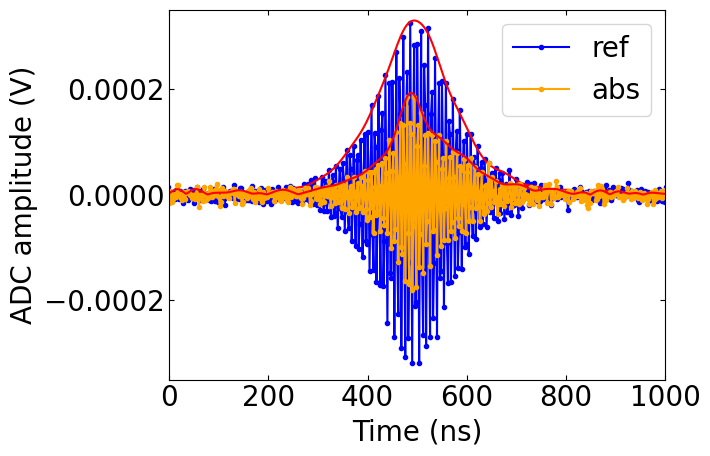

In [28]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1028_pc
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 140e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00035, 0.00035)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

87.11


<Figure size 800x300 with 0 Axes>

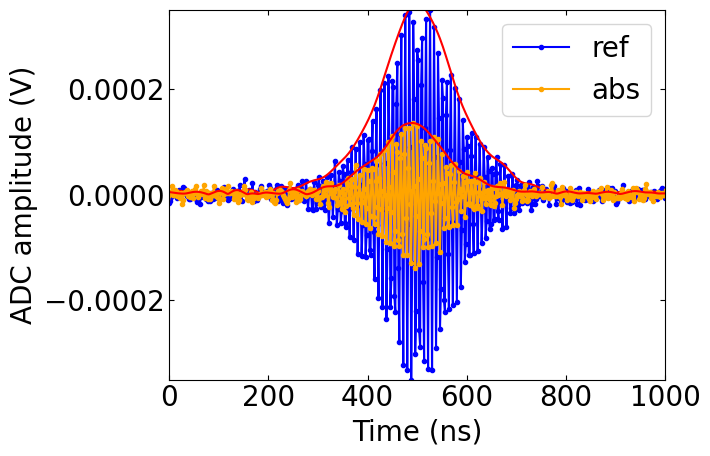

In [27]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1030_pc
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00035, 0.00035)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

84.31


<Figure size 800x300 with 0 Axes>

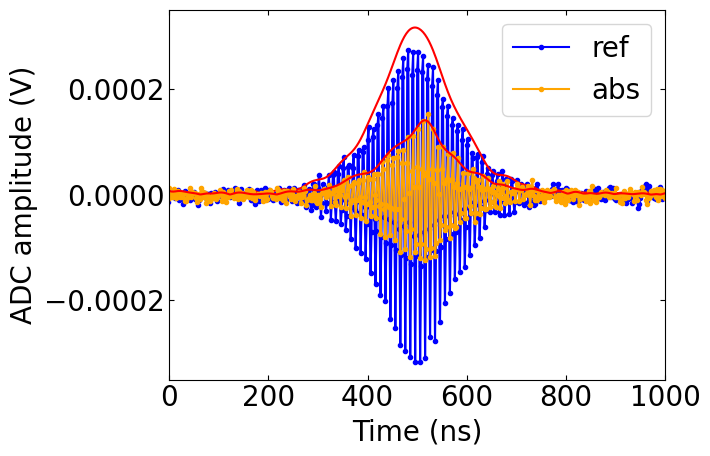

In [26]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1032_pc
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00035, 0.00035)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

before phase substraction

In [15]:
fogi_1028_pc003 = "/2024-05-30/2024-05-30T234401_0dbe9855-75-sym_JPA_ab_fogi_timing"
fogi_1030_pc003 = "/2024-05-30/2024-05-30T234624_636618fa-75-sym_JPA_ab_fogi_timing"
fogi_1032_pc003 = "/2024-05-30/2024-05-30T234850_ba2780a7-75-sym_JPA_ab_fogi_timing"

66.2


<Figure size 800x300 with 0 Axes>

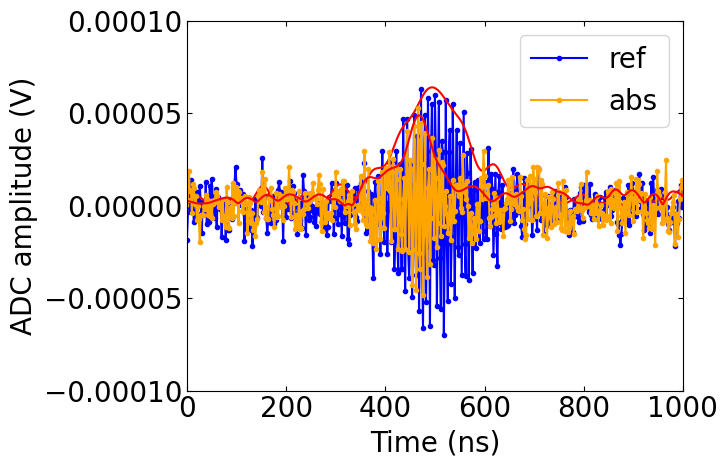

In [17]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1028_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 140e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

75.9


<Figure size 800x300 with 0 Axes>

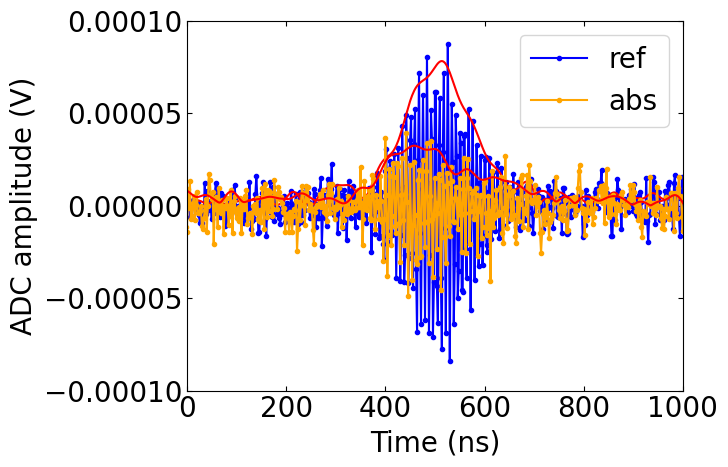

In [18]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1030_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

90.35


<Figure size 800x300 with 0 Axes>

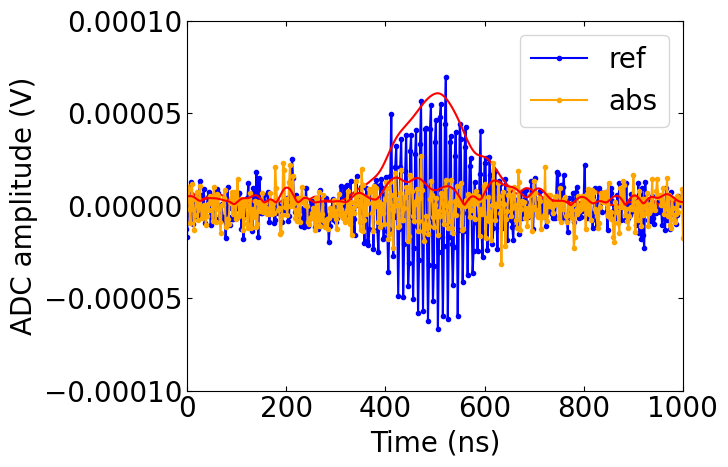

In [19]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1032_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0001, 0.0001)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()